In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
import matplotlib.patheffects as PathEffects
import numpy as np
import shoji
from typing import List, Optional
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import scipy as sci
import scanpy as sc
from scipy.stats import ks_2samp, mannwhitneyu, ttest_ind

In [2]:
#Save h5ad file from url: https://storage.googleapis.com/linnarsson-lab-glioblastoma/woundresponse/bulk_samples_Astrocytes_smartseq_2025.h5ad
#Alternatively follow the instructions at https://github.com/linnarsson-lab/shoji/blob/master/notebooks/GettingStarted_Shoji.ipynb under "Download example dataset" to create a temporary directory for the file.

In [3]:
# Load the sample data into your local Shoji database
Astrocyte = sc.read_h5ad('/home/jesper/data/bulk_samples_Astrocytes_smartseq_2025.h5ad') #Change to the path where the h5ad file has been saved 

In [4]:
Astrocyte.obs.index = [x for x in Astrocyte.obs.obs_names]

In [5]:
Astrocyte

AnnData object with n_obs × n_vars = 37 × 63757
    obs: 'Barcode', 'BarcodeIdx', 'Celltype', 'Condition', 'Hypoxia', 'ID', 'Pool', 'Sample', 'Sample_Condition', 'Sample_Time_Condition', 'Time', 'Time_Condition', 'TotalMTCounts', 'TotalReadGenes', 'TotalReads', 'TotalUMIGenes', 'TotalUMIs', 'obs_names'
    var: 'Accession', 'Chromosome'
    layers: 'Exon'

## Figure 2B

### Full list of MES1 and MES2 genes

In [6]:
MES1 = np.array(["CHI3L1","ANXA2","ANXA1","CD44","VIM","MT2A","C1S","NAMPT","EFEMP1","C1R","SOD2","IFITM3","TIMP1","SPP1","A2M","S100A11","MT1X","S100A10","FN1","LGALS1","S100A16","CLIC1","MGST1","RCAN1","TAGLN2","NPC2","SERPING1","TCIM","EMP1","APOE","CTSB","C3","LGALS3","MT1E","EMP3","SERPINA3","ACTN1","PRDX6","IGFBP7","SERPINE1","PLP2","MGP","CLIC4","GFPT2","GSN","NNMT","TUBA1C","GJA1","TNFRSF1A","WWTR1"])
MES2 = np.array(["HILPDA","ADM","DDIT3","NDRG1","HERPUD1","DNAJB9","TRIB3","ENO2","AKAP12","SQSTM1","MT1X","ATF3","NAMPT","NRN1","SLC2A1","BNIP3","LGALS3","INSIG2","IGFBP3","PPP1R15A","VIM","PLOD2","GBE1","SLC2A3","FTL","WARS1","ERO1A","XPOT","HSPA5","GDF15","ANXA2","EPAS1","LDHA","P4HA1","SERTAD1","PFKP","PGK1","EGLN3","SLC6A6","CA9","BNIP3L","RPL21","TRAM1","UFM1","ASNS","GOLT1B","ANGPTL4","SLC39A14","CDKN1A","HSPA9"])
gene_list = np.concatenate((MES1, MES2))
_, i = np.unique(gene_list, return_index=True)
gene_list = gene_list[np.sort(i)]

### Calculate fraction of total UMIs originating from the MES-genes

In [7]:
df = Astrocyte.to_df(layer=None) #Save as dataframe
df_all = df.sum(axis=1) #total UMIs per sample
MES_df = df[gene_list] # MES-genes dataframe
df_mes = MES_df.sum(axis=1) #total UMIs MES genes per sample
#Sort samples based on time
zero = Astrocyte[Astrocyte.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_mes = df_mes[zero.obs.index]
one = Astrocyte[Astrocyte.obs["Time"] == "t1"]
one_all = df_all[one.obs.index]
one_mes = df_mes[one.obs.index]
three = Astrocyte[Astrocyte.obs["Time"] == "t3"]
three_all = df_all[three.obs.index]
three_mes = df_mes[three.obs.index]
six = Astrocyte[Astrocyte.obs["Time"] == "t6"]
six_all = df_all[six.obs.index]
six_mes = df_mes[six.obs.index]
#Fraction of MES-genes UMIs of total per timepoint 
MES_zero = zero_mes/zero_all
MES_one = one_mes/one_all
MES_three = three_mes/three_all
MES_six = six_mes/six_all
#Make a dataframe with timepoint as columns
merged = pd.concat([MES_zero, MES_one, MES_three, MES_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(Astrocyte.obs.Sample_Condition)
merged1 = merged.rename(index=rename) #rename index 
merged1 = merged1.multiply(100) #multiply by 100 (display percent)
rename = dict(Astrocyte.obs.Condition)
merg = merged.rename(index=rename)
merg = merg.mean(level=0) #condense df by merging rows (mean) of same condition but different time points (columns) 
merged1 = merged1.mean(level=0) #condense df by merging rows of same sample+condition but different time points
merged1 = merged1.reindex(["SVG_1_-P-H",'SVG_2_-P-H','SVG_3_-P-H',"SVG_1_+P-H","SVG_2_+P-H","SVG_3_+P-H","SVG_1_-P+H",'SVG_2_-P+H','SVG_3_-P+H',"SVG_1_+P+H",'SVG_2_+P+H','SVG_3_+P+H'])
merged1['0'] = dict(zip(merged1.index,np.concatenate(np.repeat([merged1[0:3]['0']], 4, axis=0)))) #Repeat values for time point zero (before treatment) for all three replicates across conditions.
merged2 = merged1
merged1 = merged1.rename(index=dict(zip(merged1.index,["-P-H",'-P-H','-P-H',"+P-H","+P-H","+P-H","-P+H",'-P+H','-P+H',"+P+H",'+P+H','+P+H'])))
merg = merg.reindex(['-P-H', '+P-H','-P+H','+P+H'])
merg = merg.replace(np.nan, merg.iloc[0][0]) ##Repeat values for time point zero (before treatment) for all conditions
merg = merg.multiply(100)
merged2

,0,24,72,144
SVG_1_-P-H,2.717740,2.887754,2.786009,2.816845
SVG_2_-P-H,3.098499,2.931262,2.798626,NaN
SVG_3_-P-H,3.327716,3.051045,2.703750,2.809827
SVG_1_+P-H,2.717740,3.003360,2.895103,3.191637
SVG_2_+P-H,3.098499,NaN,3.043435,2.912175
SVG_3_+P-H,3.327716,3.141867,3.226490,2.775054
SVG_1_-P+H,2.717740,2.913179,2.725938,2.597127
SVG_2_-P+H,3.098499,3.295846,3.412694,2.690048
SVG_3_-P+H,3.327716,3.379380,3.363513,3.841841
SVG_1_+P+H,2.717740,3.886487,3.739584,2.891553


In [9]:
merg

,0,24,72,144
-P-H,3.047985,2.956687,2.762795,2.813336
+P-H,3.047985,3.072614,3.055009,2.959622
-P+H,3.047985,3.196135,3.167382,3.043005
+P+H,3.047985,3.890090,4.208327,2.886465


### Abbreviations in dataframe
#### 'P' = Plasma, 'H' = Hypoxia
#### no treatment (-P-H), plasma (+P-H), hypoxia (-P+H), hypoxia+plasma (+P+H)

In [12]:
merg.index[0]

'-P-H'

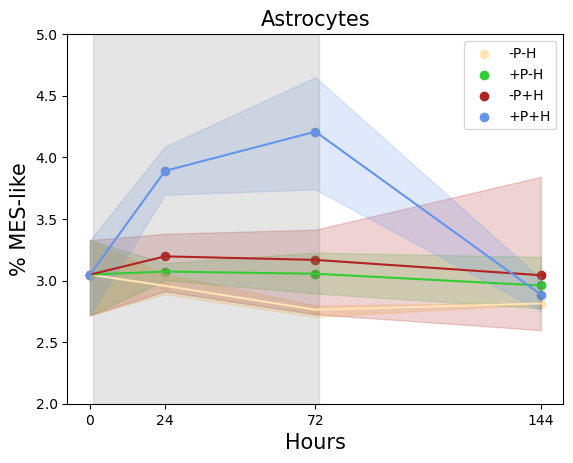

In [8]:
#Plot data (mean) including control-condition and create shaded areas instead of whiskers
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='moccasin')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='limegreen')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='firebrick')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='cornflowerblue')
plt.plot(numb, merg.iloc[0], color='moccasin')
plt.fill_between(numb,np.min(merged1[0:3]),np.max(merged1[0:3]), color='moccasin', alpha=0.6) #fill/shaded region instead of whiskers
plt.plot(numb, merg.iloc[1], color='limegreen') 
plt.fill_between(numb,np.min(merged1[3:6]),np.max(merged1[3:6]), color='limegreen', alpha=0.2) #fill/shaded region instead of whiskers
plt.plot(numb, merg.iloc[2], color='firebrick')
plt.fill_between(numb,np.min(merged1[6:9]),np.max(merged1[6:9]), color='firebrick', alpha=0.2) #fill/shaded region instead of whiskers
plt.plot(numb, merg.iloc[3], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[9:12]),np.max(merged1[9:12]), color='cornflowerblue', alpha=0.2)
plt.ylim(2, 5)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% MES-like', fontsize=15)
plt.title('Astrocytes', fontsize=15)
plt.xticks(numb)
tr = numb +1.1 #shaded area, shift a bit to the right
plt.fill_between(tr, 5, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

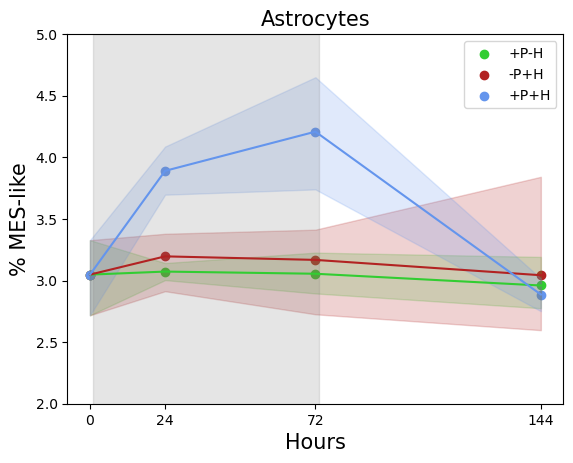

In [9]:
#Plot data (mean)  excluding control and create shaded areas instead of whiskers
numb = merg.columns.astype(int)
#plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='grey') EXCLUDE CONTROL
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='limegreen')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='firebrick')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='cornflowerblue')
plt.plot(numb, merg.iloc[1], color='limegreen')
plt.fill_between(numb,np.min(merged1[3:6]),np.max(merged1[3:6]), color='limegreen', alpha=0.2) #fill/shaded region instead of whiskers
plt.plot(numb, merg.iloc[2], color='firebrick')
plt.fill_between(numb,np.min(merged1[6:9]),np.max(merged1[6:9]), color='firebrick', alpha=0.2) #fill/shaded region instead of whiskers
plt.plot(numb, merg.iloc[3], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[9:12]),np.max(merged1[9:12]), color='cornflowerblue', alpha=0.2) #fill/shaded region instead of whiskers
plt.ylim(2, 5)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% MES-like', fontsize=15)
plt.title('Astrocytes', fontsize=15)
plt.xticks(numb)
tr = numb +1.1 #shaded area, shift a bit to the right
plt.fill_between(tr, 5, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

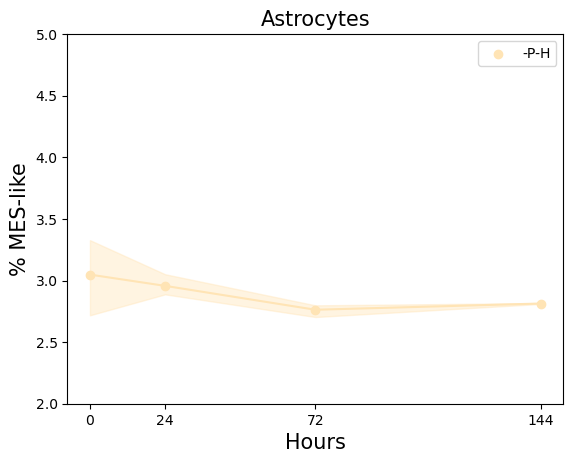

In [10]:
#Plot control (mean)
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='moccasin')
plt.plot(numb, merg.iloc[0], color='moccasin')
plt.fill_between(numb,np.min(merged1[0:3]),np.max(merged1[0:3]), color='moccasin', alpha=0.4)
plt.ylim(2, 5)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% MES-like', fontsize=15)
plt.title('Astrocytes', fontsize=15)
plt.xticks(numb)
tr = numb +3

### Statistics

In [11]:
#One-sided test
#+p-h all timepoints vs start
x, p1 = mannwhitneyu(merged1[3:6]['0'], merged1[3:6]['24'].dropna(how='all'), alternative='less')
x, p2 = mannwhitneyu(merged1[3:6]['0'], merged1[3:6]['72'], alternative='less')
x, p3 = mannwhitneyu(merged1[3:6]['0'], merged1[3:6]['144'], alternative='less') 
#-p+h all timepoints vs start
x, p4 = mannwhitneyu(merged1[6:9]['0'], merged1[6:9]['24'], alternative='less')
x, p5 = mannwhitneyu(merged1[6:9]['0'], merged1[6:9]['72'], alternative='less')
x, p6 = mannwhitneyu(merged1[6:9]['0'], merged1[6:9]['144'], alternative='less') 
#+p+h all timepoints vs start
x, p7 = mannwhitneyu(merged1[9:12]['0'], merged1[9:12]['24'], alternative='less')
x, p8 = mannwhitneyu(merged1[9:12]['0'], merged1[9:12]['72'], alternative='less')
x, p9 = mannwhitneyu(merged1[9:12]['0'], merged1[9:12]['144'], alternative='less') 

In [12]:
comp = ['+p-H_24vs0h','+p-H_72vs0h','+p-H_144vs0h','-p+H_24vs0h','-p+H_72vs0h','-p+H_144vs0h','+p+H_24vs0h','+p+H_72vs0h','+p+H_144vs0h']
x = pd.Series([p1,p2,p3,p4,p5,p6,p7,p8,p9], index =comp)
x

+p-H_24vs0h     0.60
+p-H_72vs0h     0.65
+p-H_144vs0h    0.65
-p+H_24vs0h     0.35
-p+H_72vs0h     0.20
-p+H_144vs0h    0.80
+p+H_24vs0h     0.05
+p+H_72vs0h     0.05
+p+H_144vs0h    0.80
dtype: float64

In [13]:
#One-sided test
x, p2 =  mannwhitneyu(merged1[3:6]['72'], merged1[3:6]['144'], alternative='greater')
x, p2 =  mannwhitneyu(merged1[6:9]['72'], merged1[6:9]['144'], alternative='greater')
x, p3 = mannwhitneyu(merged1[9:12]['72'], merged1[9:12]['144'], alternative='greater')

In [14]:
comp = ['+p-H_72vs144h','-p+H_72vs144h','+p+H_72vs144h']
x = pd.Series([p1,p2,p3], index =comp)
x

+p-H_72vs144h    0.60
-p+H_72vs144h    0.35
+p+H_72vs144h    0.05
dtype: float64

## Fig S8A

### Full list other neftel-states

In [15]:
AC = np.array(["CST3","S100B","SLC1A3","HEPN1","HOPX","MT3","SPARCL1","MLC1","GFAP","FABP7","BCAN","PON2","METTL7B","SPARC","GATM","RAMP1","PMP2","AQP4","DBI","EDNRB","PTPRZ1","CLU","PMP22","ATP1A2","S100A16","HEY1","PCDHGC3","TTYH1","NDRG2","PRCP","ATP1B2","AGT","PLTP","GPM6B","F3","RAB31","PLPP3","ANXA5","TSPAN7"])
OPC = np.array(["BCAN","PLP1","GPR17","FIBIN","LHFPL3","OLIG1","PSAT1","SCRG1","OMG","APOD","SIRT2","TNR","THY1","PHYHIPL","SOX2-OT","NKAIN4","PLPPR1","PTPRZ1","VCAN","DBI","PMP2","CNP","TNS3","LIMA1","CA10","PCDHGC3","CNTN1","SCD5","P2RX7","CADM2","TTYH1","FGF12","PACC1","NEU4","FXYD6","RNF13","RTKN","GPM6B","LMF1","ALCAM","PGRMC1","PLAAT1","BCAS1","RAB31","PLLP","FABP5","NLGN3","SERINC5","EPB41L2","GPR37L1"])
NPC1 = np.array(["DLL3","DLL1","SOX4","TUBB3","HES6","TAGLN3","NEU4","MARCKSL1","CD24","STMN1","TCF12","BEX1","OLIG1","MAP2","FXYD6","PTPRS","MLLT11","NPPA","BCAN","MEST","ASCL1","BTG2","DCX","NXPH1","JPT1","PFN2","SCG3","MYT1","CHD7","ADGRG1","TUBA1A","PCBP4","ETV1","SHD","TNR","AMOTL2","DBN1","HIP1","ABAT","ELAVL4","LMF1","GRIK2","SERINC5","TSPAN13","ELMO1","GLCCI1","SEZ6L","LRRN1","SEZ6","SOX11"])
NPC2 = np.array(["STMN2","CD24","RND3","NSG2","TUBB3","MIAT","DCX","NSG1","ELAVL4","MLLT11","DLX6-AS1","SOX11","NREP","FNBP1L","TAGLN3","STMN4","DLX5","SOX4","MAP1B","RBFOX2","IGFBPL1","STMN1","JPT1","DPYSL3","SEPTIN3","PKIA","ATP1B1","DYNC1I1","CD200","SNAP25","PAK3","NDRG4","KIF5A","UCHL1","ENO2","KIF5C","DDAH2","TUBB2A","LBH","LINC01102","TCF4","GNG3","NFIB","DPYSL5","CRABP1","DBN1","NFIX","CEP170","BLCAP"])
NPC = np.concatenate((NPC1, NPC2))

In [16]:
df = Astrocyte.to_df(layer=None) #Save as dataframe
df_all = df.sum(axis=1) #total UMIs per sample
OPC_df = df[OPC] #OPC genes dataframe
df_OPC = OPC_df.sum(axis=1) #total UMIs OPC genes per sample
#Sort samples based on time
zero = Astrocyte[Astrocyte.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_OPC = df_OPC[zero.obs.index]
one = Astrocyte[Astrocyte.obs["Time"] == "t1"]
one_all = df_all[one.obs.index]
one_OPC = df_OPC[one.obs.index]
three = Astrocyte[Astrocyte.obs["Time"] == "t3"]
three_all = df_all[three.obs.index]
three_OPC = df_OPC[three.obs.index]
six = Astrocyte[Astrocyte.obs["Time"] == "t6"]
six_all = df_all[six.obs.index]
six_OPC = df_OPC[six.obs.index]
#Fraction of OPC-genes UMIs of total per timepoint 
OPC_zero = zero_OPC/zero_all
OPC_one = one_OPC/one_all
OPC_three = three_OPC/three_all
OPC_six = six_OPC/six_all
#Make a dataframe with timepoint as columns
merged = pd.concat([OPC_zero, OPC_one, OPC_three, OPC_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(Astrocyte.obs.Sample_Condition)
merged1 = merged.rename(index=rename) #rename index 
merged1 = merged1.multiply(100) #multiply by 100 (display percent)
rename = dict(Astrocyte.obs.Condition)
merg = merged.rename(index=rename)
merg = merg.mean(level=0) #condense df by merging rows (mean) of same condition but different time points (columns) 
merged1 = merged1.mean(level=0) #condense df by merging rows of same sample+condition but different time points
merged1 = merged1.reindex(["SVG_1_-P-H",'SVG_2_-P-H','SVG_3_-P-H',"SVG_1_+P-H","SVG_2_+P-H","SVG_3_+P-H","SVG_1_-P+H",'SVG_2_-P+H','SVG_3_-P+H',"SVG_1_+P+H",'SVG_2_+P+H','SVG_3_+P+H'])
merged1['0'] = dict(zip(merged1.index,np.concatenate(np.repeat([merged1[0:3]['0']], 4, axis=0)))) #Repeat values for time point zero (before treatment) for all three replicates across conditions.
merged2 = merged1
merged1 = merged1.rename(index=dict(zip(merged1.index,["-P-H",'-P-H','-P-H',"+P-H","+P-H","+P-H","-P+H",'-P+H','-P+H',"+P+H",'+P+H','+P+H'])))
merg = merg.reindex(['-P-H', '+P-H','-P+H','+P+H'])
merg = merg.replace(np.nan, merg.iloc[0][0]) ##Repeat values for time point zero (before treatment) for all conditions
merg = merg.multiply(100)
#merged1

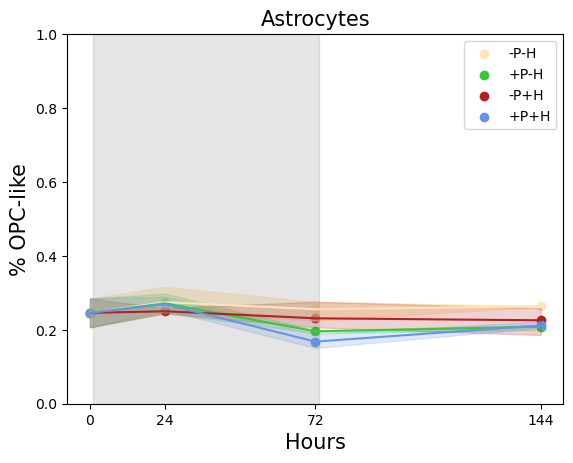

In [17]:
#Plot data (mean) including control-condition and create shaded areas instead of whiskers
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='moccasin')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='limegreen')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='firebrick')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='cornflowerblue')
plt.plot(numb, merg.iloc[0], color='moccasin')
plt.fill_between(numb,np.min(merged1[0:3]),np.max(merged1[0:3]), color='moccasin', alpha=0.6)
plt.plot(numb, merg.iloc[1], color='limegreen')
plt.fill_between(numb,np.min(merged1[3:6]),np.max(merged1[3:6]), color='limegreen', alpha=0.2)
plt.plot(numb, merg.iloc[2], color='firebrick')
plt.fill_between(numb,np.min(merged1[6:9]),np.max(merged1[6:9]), color='firebrick', alpha=0.2)
plt.plot(numb, merg.iloc[3], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[9:12]),np.max(merged1[9:12]), color='cornflowerblue', alpha=0.2)
plt.ylim(0, 1)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% OPC-like', fontsize=15)
plt.title('Astrocytes', fontsize=15)
plt.xticks(numb)
tr = numb +1.1 #shaded area, shift a bit to the right
plt.fill_between(tr, 5, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

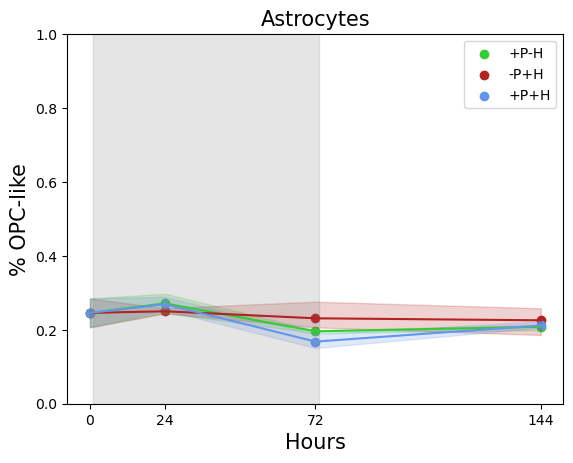

In [18]:
#Plot data (mean) excluding control and create shaded areas instead of whiskers
numb = merg.columns.astype(int)
#plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='grey') EXCLUDE CONTROL
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='limegreen')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='firebrick')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='cornflowerblue')
plt.plot(numb, merg.iloc[1], color='limegreen')
plt.fill_between(numb,np.min(merged1[3:6]),np.max(merged1[3:6]), color='limegreen', alpha=0.2)
plt.plot(numb, merg.iloc[2], color='firebrick')
plt.fill_between(numb,np.min(merged1[6:9]),np.max(merged1[6:9]), color='firebrick', alpha=0.2)
plt.plot(numb, merg.iloc[3], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[9:12]),np.max(merged1[9:12]), color='cornflowerblue', alpha=0.2)
plt.ylim(0, 1)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% OPC-like', fontsize=15)
plt.title('Astrocytes', fontsize=15)
plt.xticks(numb)
tr = numb +1.1
plt.fill_between(tr, 5, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

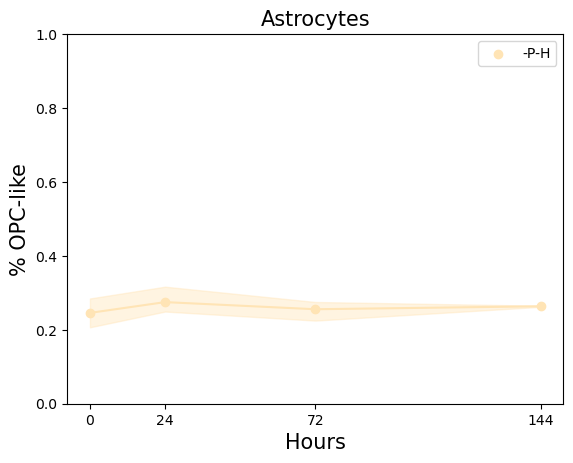

In [19]:
#Plot control (mean)
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='moccasin')
plt.plot(numb, merg.iloc[0], color='moccasin')
plt.fill_between(numb,np.min(merged1[0:3]),np.max(merged1[0:3]), color='moccasin', alpha=0.4)
plt.ylim(0, 1)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% OPC-like', fontsize=15)
plt.title('Astrocytes', fontsize=15)
plt.xticks(numb)
tr = numb +3
plt.show()

In [20]:
df = Astrocyte.to_df(layer=None) #Save as dataframe
df_all = df.sum(axis=1) #total UMIs per sample
AC_df = df[AC] #AC genes dataframe
df_AC = AC_df.sum(axis=1) #total UMIs AC genes per sample
#Sort samples based on time
zero = Astrocyte[Astrocyte.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_AC = df_AC[zero.obs.index]
one = Astrocyte[Astrocyte.obs["Time"] == "t1"]
one_all = df_all[one.obs.index]
one_AC = df_AC[one.obs.index]
three = Astrocyte[Astrocyte.obs["Time"] == "t3"]
three_all = df_all[three.obs.index]
three_AC = df_AC[three.obs.index]
six = Astrocyte[Astrocyte.obs["Time"] == "t6"]
six_all = df_all[six.obs.index]
six_AC = df_AC[six.obs.index]
#Fraction of AC-genes UMIs of total per timepoint 
AC_zero = zero_AC/zero_all
AC_one = one_AC/one_all
AC_three = three_AC/three_all
AC_six = six_AC/six_all
#Make a dataframe with timepoint as columns
merged = pd.concat([AC_zero, AC_one, AC_three, AC_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(Astrocyte.obs.Sample_Condition)
merged1 = merged.rename(index=rename) #rename index 
merged1 = merged1.multiply(100) #multiply by 100 (display percent)
rename = dict(Astrocyte.obs.Condition)
merg = merged.rename(index=rename)
merg = merg.mean(level=0) #condense df by merging rows (mean) of same condition but different time points (columns) 
merged1 = merged1.mean(level=0) #condense df by merging rows of same sample+condition but different time points
merged1 = merged1.reindex(["SVG_1_-P-H",'SVG_2_-P-H','SVG_3_-P-H',"SVG_1_+P-H","SVG_2_+P-H","SVG_3_+P-H","SVG_1_-P+H",'SVG_2_-P+H','SVG_3_-P+H',"SVG_1_+P+H",'SVG_2_+P+H','SVG_3_+P+H'])
merged1['0'] = dict(zip(merged1.index,np.concatenate(np.repeat([merged1[0:3]['0']], 4, axis=0)))) #Repeat values for time point zero (before treatment) for all three replicates across conditions.
merged2 = merged1
merged1 = merged1.rename(index=dict(zip(merged1.index,["-P-H",'-P-H','-P-H',"+P-H","+P-H","+P-H","-P+H",'-P+H','-P+H',"+P+H",'+P+H','+P+H'])))
merg = merg.reindex(['-P-H', '+P-H','-P+H','+P+H'])
merg = merg.replace(np.nan, merg.iloc[0][0]) ##Repeat values for time point zero (before treatment) for all conditions
merg = merg.multiply(100)
#merged1

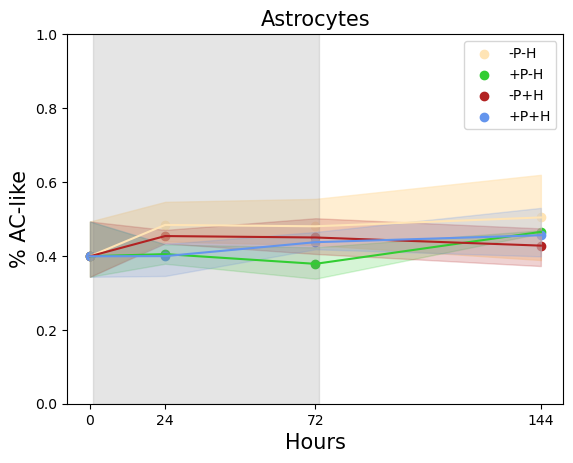

In [21]:
#Plot data (mean) including control-condition and create shaded areas instead of whiskers
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='moccasin')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='limegreen')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='firebrick')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='cornflowerblue')
plt.plot(numb, merg.iloc[0], color='moccasin')
plt.fill_between(numb,np.min(merged1[0:3]),np.max(merged1[0:3]), color='moccasin', alpha=0.6)
plt.plot(numb, merg.iloc[1], color='limegreen')
plt.fill_between(numb,np.min(merged1[3:6]),np.max(merged1[3:6]), color='limegreen', alpha=0.2)
plt.plot(numb, merg.iloc[2], color='firebrick')
plt.fill_between(numb,np.min(merged1[6:9]),np.max(merged1[6:9]), color='firebrick', alpha=0.2)
plt.plot(numb, merg.iloc[3], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[9:12]),np.max(merged1[9:12]), color='cornflowerblue', alpha=0.2)
plt.ylim(0, 1)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% AC-like', fontsize=15)
plt.title('Astrocytes', fontsize=15)
plt.xticks(numb)
tr = numb +1.1 #shaded area, shift a bit to the right
plt.fill_between(tr, 5, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

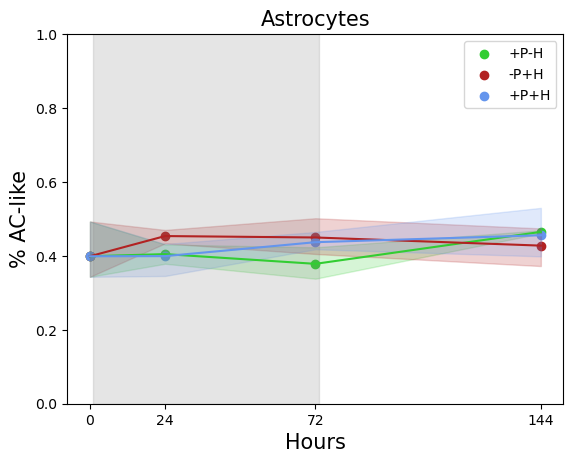

In [22]:
#Plot data (mean) excluding control and create shaded areas instead of whiskers
numb = merg.columns.astype(int)
#plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='grey') EXCLUDE CONTROL
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='limegreen')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='firebrick')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='cornflowerblue')
plt.plot(numb, merg.iloc[1], color='limegreen')
plt.fill_between(numb,np.min(merged1[3:6]),np.max(merged1[3:6]), color='limegreen', alpha=0.2)
plt.plot(numb, merg.iloc[2], color='firebrick')
plt.fill_between(numb,np.min(merged1[6:9]),np.max(merged1[6:9]), color='firebrick', alpha=0.2)
plt.plot(numb, merg.iloc[3], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[9:12]),np.max(merged1[9:12]), color='cornflowerblue', alpha=0.2)
plt.ylim(0, 1)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% AC-like', fontsize=15)
plt.title('Astrocytes', fontsize=15)
plt.xticks(numb)
tr = numb +1.1
plt.fill_between(tr, 5, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

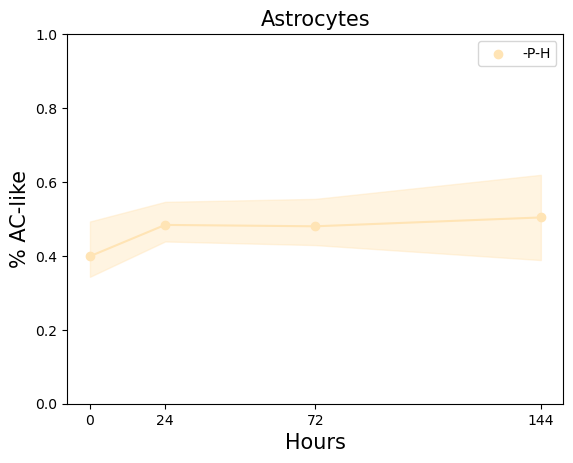

In [23]:
#Plot control (mean)
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='moccasin')
plt.plot(numb, merg.iloc[0], color='moccasin')
plt.fill_between(numb,np.min(merged1[0:3]),np.max(merged1[0:3]), color='moccasin', alpha=0.4)
plt.ylim(0, 1)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% AC-like', fontsize=15)
plt.title('Astrocytes', fontsize=15)
plt.xticks(numb)
tr = numb +3
plt.show()

In [24]:
df = Astrocyte.to_df(layer=None) #Save as dataframe
df_all = df.sum(axis=1) #total UMIs per sample
NPC_df = df[NPC] #NPC genes dataframe
df_NPC = NPC_df.sum(axis=1) #total UMIs NPC genes per sample
#Sort samples based on time
zero = Astrocyte[Astrocyte.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_NPC = df_NPC[zero.obs.index]
one = Astrocyte[Astrocyte.obs["Time"] == "t1"]
one_all = df_all[one.obs.index]
one_NPC = df_NPC[one.obs.index]
three = Astrocyte[Astrocyte.obs["Time"] == "t3"]
three_all = df_all[three.obs.index]
three_NPC = df_NPC[three.obs.index]
six = Astrocyte[Astrocyte.obs["Time"] == "t6"]
six_all = df_all[six.obs.index]
six_NPC = df_NPC[six.obs.index]
#Fraction of NPC-genes UMIs of total per timepoint 
NPC_zero = zero_NPC/zero_all
NPC_one = one_NPC/one_all
NPC_three = three_NPC/three_all
NPC_six = six_NPC/six_all
#Make a dataframe with timepoint as columns
merged = pd.concat([NPC_zero, NPC_one, NPC_three, NPC_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(Astrocyte.obs.Sample_Condition)
merged1 = merged.rename(index=rename) #rename index 
merged1 = merged1.multiply(100) #multiply by 100 (display percent)
rename = dict(Astrocyte.obs.Condition)
merg = merged.rename(index=rename)
merg = merg.mean(level=0) #condense df by merging rows (mean) of same condition but different time points (columns) 
merged1 = merged1.mean(level=0) #condense df by merging rows of same sample+condition but different time points
merged1 = merged1.reindex(["SVG_1_-P-H",'SVG_2_-P-H','SVG_3_-P-H',"SVG_1_+P-H","SVG_2_+P-H","SVG_3_+P-H","SVG_1_-P+H",'SVG_2_-P+H','SVG_3_-P+H',"SVG_1_+P+H",'SVG_2_+P+H','SVG_3_+P+H'])
merged1['0'] = dict(zip(merged1.index,np.concatenate(np.repeat([merged1[0:3]['0']], 4, axis=0)))) #Repeat values for time point zero (before treatment) for all three replicates across conditions.
merged2 = merged1
merged1 = merged1.rename(index=dict(zip(merged1.index,["-P-H",'-P-H','-P-H',"+P-H","+P-H","+P-H","-P+H",'-P+H','-P+H',"+P+H",'+P+H','+P+H'])))
merg = merg.reindex(['-P-H', '+P-H','-P+H','+P+H'])
merg = merg.replace(np.nan, merg.iloc[0][0]) ##Repeat values for time point zero (before treatment) for all conditions
merg = merg.multiply(100)
#merged1

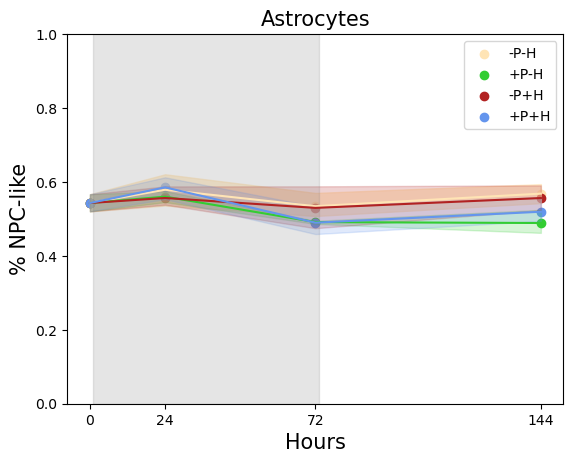

In [25]:
#Plot data (mean) including control-condition and create shaded areas instead of whiskers
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='moccasin')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='limegreen')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='firebrick')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='cornflowerblue')
plt.plot(numb, merg.iloc[0], color='moccasin')
plt.fill_between(numb,np.min(merged1[0:3]),np.max(merged1[0:3]), color='moccasin', alpha=0.6)
plt.plot(numb, merg.iloc[1], color='limegreen')
plt.fill_between(numb,np.min(merged1[3:6]),np.max(merged1[3:6]), color='limegreen', alpha=0.2)
plt.plot(numb, merg.iloc[2], color='firebrick')
plt.fill_between(numb,np.min(merged1[6:9]),np.max(merged1[6:9]), color='firebrick', alpha=0.2)
plt.plot(numb, merg.iloc[3], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[9:12]),np.max(merged1[9:12]), color='cornflowerblue', alpha=0.2)
plt.ylim(0, 1)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% NPC-like', fontsize=15)
plt.title('Astrocytes', fontsize=15)
plt.xticks(numb)
tr = numb +1.1 #shaded area, shift a bit to the right
plt.fill_between(tr, 5, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

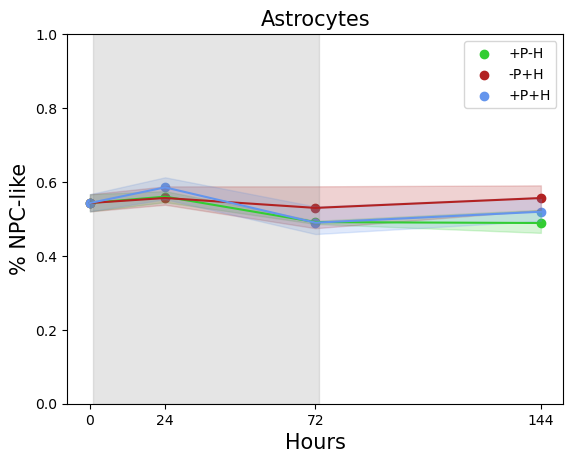

In [26]:
#Plot data (mean) excluding control and create shaded areas instead of whiskers
numb = merg.columns.astype(int)
#plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='grey') EXCLUDE CONTROL
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='limegreen')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='firebrick')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='cornflowerblue')
plt.plot(numb, merg.iloc[1], color='limegreen')
plt.fill_between(numb,np.min(merged1[3:6]),np.max(merged1[3:6]), color='limegreen', alpha=0.2)
plt.plot(numb, merg.iloc[2], color='firebrick')
plt.fill_between(numb,np.min(merged1[6:9]),np.max(merged1[6:9]), color='firebrick', alpha=0.2)
plt.plot(numb, merg.iloc[3], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[9:12]),np.max(merged1[9:12]), color='cornflowerblue', alpha=0.2)
plt.ylim(0, 1)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% NPC-like', fontsize=15)
plt.title('Astrocytes', fontsize=15)
plt.xticks(numb)
tr = numb +1.1
plt.fill_between(tr, 5, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

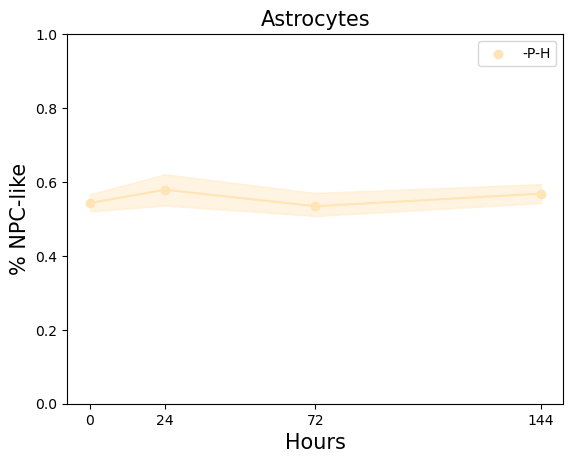

In [27]:
#Plot control (mean)
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='moccasin')
plt.plot(numb, merg.iloc[0], color='moccasin')
plt.fill_between(numb,np.min(merged1[0:3]),np.max(merged1[0:3]), color='moccasin', alpha=0.4)
plt.ylim(0, 1)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% NPC-like', fontsize=15)
plt.title('Astrocytes', fontsize=15)
plt.xticks(numb)
tr = numb +3
plt.show()